In [1]:
from google.colab import files

uploaded = files.upload()


Saving Mall_Customers.csv to Mall_Customers.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

In [3]:
df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [6]:
from sklearn.preprocessing import StandardScaler

In [8]:
# Select the features for clustering
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

X.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [9]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=5, random_state=42, n_init=10))
])

pipeline.fit(X)

clusters = pipeline.predict(X)

In [11]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [12]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters_kmeans = kmeans.fit_predict(X_scaled)

In [13]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, clusters_kmeans)

print("Silhouette Score:", score)

Silhouette Score: 0.41664341513732767


In [14]:
from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(
    n_clusters=5
)

clusters_hierarchical = hierarchical.fit_predict(X_scaled)

In [15]:
score_hierarchical = silhouette_score(
    X_scaled,
    clusters_hierarchical
)

print("Hierarchical Silhouette Score:",
      score_hierarchical)

Hierarchical Silhouette Score: 0.39002826186267214


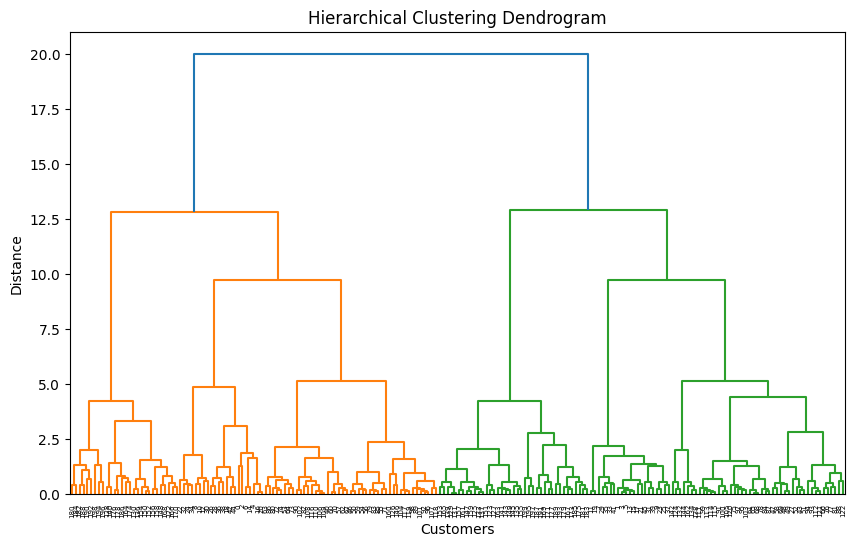

In [16]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10, 6))

dendrogram(linked)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")

plt.show()

In [17]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

clusters_dbscan = dbscan.fit_predict(X_scaled)

In [18]:
import numpy as np
from sklearn.metrics import silhouette_score

labels = clusters_dbscan

unique_labels = set(labels)

if len(unique_labels - {-1}) > 1:

    mask = labels != -1

    score_dbscan = silhouette_score(
        X_scaled[mask],
        labels[mask]
    )

    print("DBSCAN Silhouette Score:",
          score_dbscan)

else:
    print("Silhouette Score cannot be calculated.")

DBSCAN Silhouette Score: 0.481714917862304


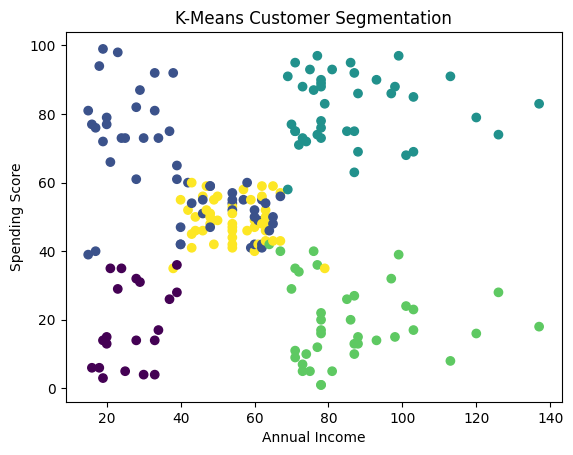

In [19]:
plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=clusters_kmeans
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("K-Means Customer Segmentation")

plt.show()

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score

# -----------------------------
# 1. Select features
# -----------------------------
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

# -----------------------------
# 2. Standardize data
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# 3. K-Means
# -----------------------------
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

kmeans_score = silhouette_score(
    X_scaled,
    kmeans_labels
)

# -----------------------------
# 4. Hierarchical Clustering
# -----------------------------
hierarchical = AgglomerativeClustering(
    n_clusters=5
)

hierarchical_labels = hierarchical.fit_predict(X_scaled)

hierarchical_score = silhouette_score(
    X_scaled,
    hierarchical_labels
)

# -----------------------------
# 5. DBSCAN
# -----------------------------
dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)

# Remove noise points (-1) for silhouette calculation
mask = dbscan_labels != -1

if len(set(dbscan_labels[mask])) >= 2:
    dbscan_score = silhouette_score(
        X_scaled[mask],
        dbscan_labels[mask]
    )
else:
    dbscan_score = None

# -----------------------------
# 6. Print results
# -----------------------------
print("K-Means Silhouette Score:", kmeans_score)
print("Hierarchical Silhouette Score:", hierarchical_score)
print("DBSCAN Silhouette Score:", dbscan_score)

K-Means Silhouette Score: 0.41664341513732767
Hierarchical Silhouette Score: 0.39002826186267214
DBSCAN Silhouette Score: 0.481714917862304


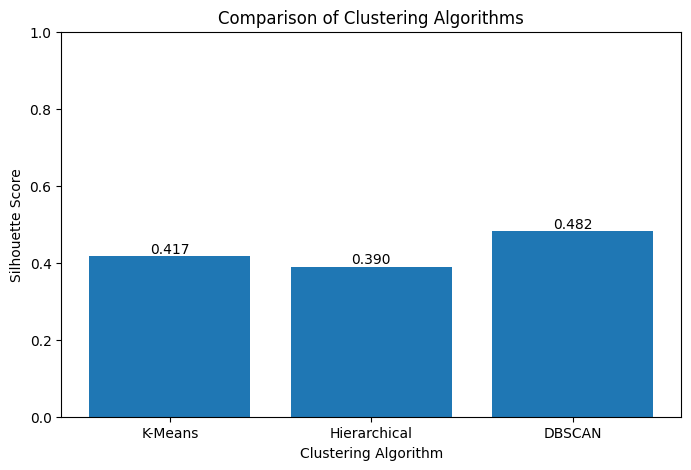

In [21]:
# -----------------------------
# 7. Compare the algorithms
# -----------------------------

algorithms = [
    "K-Means",
    "Hierarchical",
    "DBSCAN"
]

scores = [
    kmeans_score,
    hierarchical_score,
    dbscan_score if dbscan_score is not None else 0
]

plt.figure(figsize=(8, 5))

bars = plt.bar(algorithms, scores)

plt.xlabel("Clustering Algorithm")
plt.ylabel("Silhouette Score")
plt.title("Comparison of Clustering Algorithms")

plt.ylim(0, 1)

# Display score on top of each bar
for bar, score in zip(bars, scores):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{score:.3f}",
        ha='center',
        va='bottom'
    )

plt.show()

In [22]:
results = pd.DataFrame({
    "Algorithm": algorithms,
    "Silhouette Score": scores
})

print(results)

      Algorithm  Silhouette Score
0       K-Means          0.416643
1  Hierarchical          0.390028
2        DBSCAN          0.481715


In [23]:
best_algorithm = algorithms[scores.index(max(scores))]

print("Best Clustering Algorithm:", best_algorithm)

Best Clustering Algorithm: DBSCAN
